## Before you run this

**Training writes to `runs/`, never to `dataset/checkpoints/`.** Every config now sets
`overwrite: false`, so if the target directory already exists the run aborts with
`FileExistsError` instead of silently deleting a published checkpoint. Rename or remove
the directory under `runs/` when you want to re-run.

**`Run All` trains from scratch.** The teacher takes 75 epochs, the student up to 1000
(with early stopping). To only check that the pipeline is wired up, run the cells up to
the first validation and interrupt, or lower `epochs` in the config.

**Hyperparameter search is off** (`USE_OPTUNA = False`). Turning it on re-runs the
Optuna study, which took hours per notebook.


In [ ]:
# ── Output safety ────────────────────────────────────────────────────────────
# Training writes to runs/<RUN_NAME>/. It never touches dataset/checkpoints/,
# which holds the published results this repository reports.
RUN_NAME  = "my_run"     # one directory per experiment
OVERWRITE = False        # False: abort if runs/<RUN_NAME> exists. True: wipe it first.

# Which weights the evaluation cells load:
#   "published" -> dataset/checkpoints/...  (reproduce the reported numbers)
#   "mine"      -> runs/<RUN_NAME>/...      (evaluate what you just trained)
EVAL_CKPT = "published"


# Cross-Modal Feature Distillation with a Shared Vocabulary (FD-CMKD)

Finetuning of the **Signformer student** (I3D features) with the **complete FD-CMKD
method** of Liu et al. (2025), *"Distilling Cross-Modal Knowledge via Feature
Disentanglement"*, using the **skeleton model** (75-keypoint TSSI) as teacher.

| Paper component | Implementation |
|---|---|
| Frequency decoupling (Eq. 1-3) | DFT along the feature dim, half-band masks, inverse DFT |
| Scale alignment (Eq. 7) | per-frame standardisation (zero mean, unit L2) |
| Low-frequency loss (Eq. 8) | MSE between standardised low-band features |
| High-frequency loss (Eq. 9) | logMSE with signed log compression (Eq. 6) |
| Feature space alignment (Eq. 10) | **shared classifiers** Phi_low / Phi_high over a **single shared gloss vocabulary**, trained with CTC on both modalities |

The shared vocabulary is built deterministically from the student gloss vocabulary
with the same merge policy used by the skeleton teacher (orthographic similarity +
hyphen normalisation, with merge-chain resolution).

**Prerequisites**
1. Teacher features: `dataset/features/skeleton_feats/{train,dev,test}.pkl`
2. Student checkpoint: `code/signformer/sign_sample/best.ckpt`

**Outputs**: best model and curves in `dataset/checkpoints/fd_cmkd/`.

## 0 — Setup: paths, imports, defensive patches

In [1]:
import os, sys, copy, gc, pickle, logging
from pathlib import Path

NB_DIR = Path.cwd()
while NB_DIR.name != 'distillation' and NB_DIR.parent != NB_DIR:
    NB_DIR = NB_DIR.parent
os.chdir(NB_DIR)
SIGNFORMER_DIR = (NB_DIR.parent / 'signformer').resolve()
sys.path.insert(0, str(SIGNFORMER_DIR))   # `import main.*` (shared framework)
sys.path.insert(0, str(NB_DIR))           # `import fd_cmkd`, `fd_cmkd_trainer`
print('cwd            :', os.getcwd())
print('signformer path:', SIGNFORMER_DIR)
assert (SIGNFORMER_DIR / 'main').is_dir(), 'code/signformer/main not found'

import torch, yaml
import main.training as mt
import fd_cmkd_trainer as FT
from fd_cmkd import load_teacher_feats, build_shared_vocab
torch.backends.cudnn.enabled = False
logging.getLogger().setLevel(logging.ERROR)

# Defensive patches (idempotent): tolerate the extra optimizer param group in
# ReduceLROnPlateau and skip the parameter-list logging of the framework.
def _safe_reduce_lr(self, epoch=None):
    for i, pg in enumerate(self.optimizer.param_groups):
        old_lr = float(pg['lr'])
        min_lr = self.min_lrs[i] if i < len(self.min_lrs) else 0.0
        new_lr = max(old_lr * self.factor, min_lr)
        if old_lr - new_lr > self.eps:
            pg['lr'] = new_lr
torch.optim.lr_scheduler.ReduceLROnPlateau._reduce_lr = _safe_reduce_lr
mt.TrainManager._log_parameters_list = lambda self: None
def _make_logger(model_dir=None, log_file='train.log', *a, **k):
    lg = logging.getLogger('fdcmkd'); lg.setLevel(logging.INFO)
    if not lg.handlers: lg.addHandler(logging.StreamHandler())
    lg.propagate = False
    return lg
mt.make_logger = _make_logger
print('setup complete')

cwd            : /home/ebufi/phoenix/code/distillation
signformer path: /home/ebufi/phoenix/code/signformer


I0000 00:00:1783629475.976903 1848635 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


setup complete


## 1 — Configuration

In [2]:
PARAMS = {
    # --- paths (relative to code/distillation/) ---
    'student_ckpt':      '../../dataset/checkpoints/sign_sample/best.ckpt',
    'teacher_feats_dir': '../../dataset/features/skeleton_feats',
    'model_dir':         None,   # set from RUN_NAME below
    'base_yaml':         'sign_distill.yaml',
    'i3d_dir':           '../../dataset/features/i3d_pami0',

    # --- FD-CMKD loss weights ---
    'enabled':      True,
    'lambda_feat':  0.5,    # weight of Eq. 8 + Eq. 9 (frequency-decoupled feature loss)
    'low_w':        1.0,    # low-frequency MSE (shared semantics — strong consistency)
    'high_w':       0.25,   # high-frequency logMSE (modality-specific — weak consistency)
    'lambda_align': 0.3,    # weight of Eq. 10 (shared-classifier CTC alignment)

    # --- training ---
    'learning_rate':           5e-5,
    'batch_size':              32,   # MOD 1: era 4 -> il training finale girava a batch effettivo 4
                                     # (BatchNorm rumorosa + mismatch con Optuna). cuDNN era il bug,
                                     # NON un OOM: sul 3080 batch 32 ci sta (valore originale).
    'validation_freq':         100,
    'early_stopping_patience': 10,
}
PARAMS
PARAMS['model_dir'] = f'../../runs/{RUN_NAME}'


{'student_ckpt': '../signformer/sign_sample/best.ckpt',
 'teacher_feats_dir': '../../dataset/features/skeleton_feats/skeleton_feats',
 'model_dir': '../../dataset/checkpoints/fd_cmkd',
 'base_yaml': 'sign_distill.yaml',
 'i3d_dir': '../../dataset/features/PHOENIX2014T',
 'enabled': True,
 'lambda_feat': 0.5,
 'low_w': 1.0,
 'high_w': 0.25,
 'lambda_align': 0.3,
 'learning_rate': 5e-05,
 'batch_size': 32,
 'validation_freq': 100,
 'early_stopping_patience': 10}

## 2 — Sanity checks (checkpoint, teacher features, shared vocabulary preview)

In [3]:
assert os.path.exists(PARAMS['student_ckpt']), \
    f"student checkpoint not found: {PARAMS['student_ckpt']}"
print('student ckpt : OK ->', PARAMS['student_ckpt'])

_tf_path = os.path.join(PARAMS['teacher_feats_dir'], 'train.pkl')
assert os.path.exists(_tf_path), f'teacher features missing: {_tf_path}'
_tf = load_teacher_feats(_tf_path)
_k = next(iter(_tf))
print(f'teacher feats: OK -> {len(_tf)} videos | dim={_tf[_k].shape[1]}')
FT.load_teacher_feats = lambda p: _tf      # cache: avoid reloading per trial/run

assert os.path.exists(PARAMS['base_yaml']), f"missing base config: {PARAMS['base_yaml']}"
with open(PARAMS['base_yaml']) as f:
    _base = yaml.safe_load(f)
# point the data section at the reorganised dataset/ tree
_base['data']['data_path'] = './'
for _split, _fname in [('train', 'phoenix14t.pami0.train'),
                       ('dev',   'phoenix14t.pami0.dev'),
                       ('test',  'phoenix14t.pami0.test')]:
    _base['data'][_split] = os.path.join(PARAMS['i3d_dir'], _fname)
print('base config  : OK ->', PARAMS['base_yaml'])

# Preview of the shared vocabulary (built from the student gloss vocabulary)
_tr, _dv, _te, _gls, _txt = mt.load_data(data_cfg=_base['data'])
_shared_vocab, _lut = build_shared_vocab(_gls)
print(f'student vocab: {len(_gls.itos)} | shared vocab: {len(_shared_vocab)} '
      f'(merged {len(_gls.itos) - len(_shared_vocab)} forms)')

student ckpt : OK -> ../signformer/sign_sample/best.ckpt
teacher feats: OK -> 7096 videos | dim=512
base config  : OK -> sign_distill.yaml
student vocab: 1087 | shared vocab: 1021 (merged 66 forms)


## 3 — Optional Optuna hyperparameter search (~30 % of the training budget)

When `USE_OPTUNA=True`, a short TPE study (reduced early-stopping patience) searches
`lambda_feat`, `lambda_align`, `high_w` and the learning rate; `PARAMS` is then updated
with the best trial. When `False`, the current `PARAMS` values are used as-is.

In [4]:
USE_OPTUNA = False   # set True to re-run the hyperparameter search (hours)
OPTUNA_TRIALS = 8
OPTUNA_FRAC   = 0.30

if USE_OPTUNA:
    torch.backends.cudnn.benchmark = False
    try:
        import optuna
        
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
        import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    import tempfile

    _sgn_dim = (sum(_base['data']['feature_size'])
                if isinstance(_base['data']['feature_size'], list)
                else _base['data']['feature_size'])
    _short_patience = max(3, int(PARAMS['early_stopping_patience'] * OPTUNA_FRAC))

    def _objective(trial):
        cfg_t = copy.deepcopy(_base)
        tr = cfg_t['training']
        tr['load_model']              = PARAMS['student_ckpt']
        tr['learning_rate']           = trial.suggest_float('lr', 2e-5, 2e-4, log=True)
        tr['batch_size']       = 32     # MOD 2: stesso regime del training finale (era 4)
        tr['batch_multiplier'] = 1      # (era 8) -> niente mismatch, BatchNorm sana anche in HPO
        tr['validation_freq']         = PARAMS['validation_freq']
        tr['early_stopping_patience'] = _short_patience
        tr['reset_best_ckpt'] = True; tr['reset_optimizer'] = True; tr['reset_scheduler'] = True
        tr['overwrite'] = True
        tr['model_dir'] = tempfile.mkdtemp(prefix='optuna_fd_', dir='.')
        tr['distillation'] = {
            'enabled': True,
            'teacher_feats_dir': PARAMS['teacher_feats_dir'],
            'lambda_feat':  trial.suggest_float('lambda_feat', 0.1, 3.0, log=True),
            'low_w':        PARAMS['low_w'],
            'high_w':       trial.suggest_float('high_w', 0.0, 1.0),
            'lambda_align': trial.suggest_float('lambda_align', 0.05, 1.0, log=True),
        }
        do_rec = tr.get('recognition_loss_weight', 1.0) > 0.0
        do_trs = tr.get('translation_loss_weight', 1.0) > 0.0
        mm = cfg_t['data'].get('multimodal', 1.0) > 0.0
        model = mt.build_model(cfg=cfg_t['model'], multimodal=mm,
                               gls_vocab=_gls, txt_vocab=_txt, sgn_dim=_sgn_dim,
                               do_recognition=do_rec, do_translation=do_trs)
        trainer = FT.FDCMKDTrainManager(model=model, config=cfg_t)
        trainer.train_and_validate(train_data=_tr, valid_data=_dv)
        wer = float(trainer.best_ckpt_score)
        del trainer, model
        gc.collect(); torch.cuda.empty_cache()
        return wer

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
    print('best dev WER :', round(study.best_value, 2))
    print('best params  :', study.best_params)
    PARAMS['learning_rate'] = study.best_params['lr']
    PARAMS['lambda_feat']   = study.best_params['lambda_feat']
    PARAMS['high_w']        = study.best_params['high_w']
    PARAMS['lambda_align']  = study.best_params['lambda_align']
    print('PARAMS updated with the best trial.')
else:
    print('Optuna disabled — using current PARAMS.')

COPE:  False
[builders] SophiaG non disponibile, uso Adam come fallback


/home/ebufi/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ebufi/venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Loading model from ../signformer/sign_sample/best.ckpt
Reset optimizer.
Reset scheduler.
Reset tracking of the best checkpoint.
FD-CMKD ON | student_dim=256 teacher_dim=512 shared_vocab=1021 | lambda_feat=2.537 low_w=1.00 high_w=0.73 lambda_align=0.300 | feats=7096
EPOCH 1
[Epoch: 001 Step: 00013300] Batch Recognition Loss:   0.914655 => Gls Tokens per Sec:     2974 || Lr: 0.000047
Hooray! New best validation result [eval_metric]!
Saving new checkpoint.
Validation result at epoch   1, step    13300: duration: 13.3000s
	Recognition Beam Size: 1	

COPE:  False
[builders] SophiaG non disponibile, uso Adam come fallback


FD-CMKD ON | student_dim=256 teacher_dim=512 shared_vocab=1021 | lambda_feat=0.170 low_w=1.00 high_w=0.06 lambda_align=0.670 | feats=7096
EPOCH 1
[Epoch: 001 Step: 00013300] Batch Recognition Loss:   1.259931 => Gls Tokens per Sec:     3261 || Lr: 0.000029
Hooray! New best validation result [eval_metric]!
Saving new checkpoint.
Validation result at epoch   1, step    13300: duration: 13.1851s
	Recognition Beam Size: 1	Translation Beam Size: -1	Translation Beam Alpha: -1
	Recognition Loss: 36.37220	Translation Loss: -1.00000	PPL: -1.00000
	Eval Metric: WER
	WER 40.82	(DEL: 16.60,	INS: 2.37,	SUB: 21.85)
	BLEU-4 -1.00	(BLEU-1: -1.00,	BLEU-2: -1.00,	BLEU-3: -1.00,	BLEU-4: -1.00)
	CHRF -1.00	ROUGE -1.00
Logging Recognition and Translation Outputs
Logging Sequence: 12July_2010_Monday_heute-244
	Gloss Reference :	DEUTSCHLAND ZWEI TEIL    REGEN SCHWUEL FRISCH  KUEHL
	Gloss Hypothesis:	DEUTSCH     LAND ZWANZIG GRAD  REGEN   KOENNEN KUEHL
	Gloss Alignment :	S           S    S       S     S      

COPE:  False
[builders] SophiaG non disponibile, uso Adam come fallback


...

COPE:  False
[builders] SophiaG non disponibile, uso Adam come fallback


FD-CMKD ON | student_dim=256 teacher_dim=512 shared_vocab=1021 | lambda_feat=1.445 low_w=1.00 high_w=0.20 lambda_align=0.233 | feats=7096
EPOCH 1
[Epoch: 001 Step: 00013300] Batch Recognition Loss:   1.204669 => Gls Tokens per Sec:     3231 || Lr: 0.000057
Hooray! New best validation result [eval_metric]!
Saving new checkpoint.
Validation result at epoch   1, step    13300: duration: 13.3425s
	Recognition Beam Size: 1	Translation Beam Size: -1	Translation Beam Alpha: -1
	Recognition Loss: 36.74516	Translation Loss: -1.00000	PPL: -1.00000
	Eval Metric: WER
	WER 40.13	(DEL: 15.45,	INS: 2.56,	SUB: 22.12)
	BLEU-4 -1.00	(BLEU-1: -1.00,	BLEU-2: -1.00,	BLEU-3: -1.00,	BLEU-4: -1.00)
	CHRF -1.00	ROUGE -1.00
Logging Recognition and Translation Outputs
Logging Sequence: 14April_2010_Wednesday_heute-1880
	Gloss Reference :	INKOMMEND FRUEHLING WETTER MORGEN WARM
	Gloss Hypothesis:	MORGEN    FRUEH     WETTER MORGEN WARM
	Gloss Alignment :	S         S                           
Logging Sequence: 09De

COPE:  False
[builders] SophiaG non disponibile, uso Adam come fallback


FD-CMKD ON | student_dim=256 teacher_dim=512 shared_vocab=1021 | lambda_feat=0.117 low_w=1.00 high_w=0.61 lambda_align=0.083 | feats=7096
EPOCH 1
[Epoch: 001 Step: 00013300] Batch Recognition Loss:   1.422702 => Gls Tokens per Sec:     3102 || Lr: 0.000078
Hooray! New best validation result [eval_metric]!
Saving new checkpoint.
Validation result at epoch   1, step    13300: duration: 13.1663s
	Recognition Beam Size: 1	Translation Beam Size: -1	Translation Beam Alpha: -1
	Recognition Loss: 36.40187	Translation Loss: -1.00000	PPL: -1.00000
	Eval Metric: WER
	WER 40.21	(DEL: 16.36,	INS: 2.29,	SUB: 21.56)
	BLEU-4 -1.00	(BLEU-1: -1.00,	BLEU-2: -1.00,	BLEU-3: -1.00,	BLEU-4: -1.00)
	CHRF -1.00	ROUGE -1.00
Logging Recognition and Translation Outputs
Logging Sequence: 09August_2009_Sunday_tagesschau-1182
	Gloss Reference :	JETZT INKOMMEND IX ******** REGEN GEWITTER KOENNEN STARK
	Gloss Hypothesis:	JETZT INKOMMEND IX BISSCHEN REGEN GEWITTER ******* STARK
	Gloss Alignment :	                   I  

best dev WER : 39.54
best params  : {'lr': 8.182441148887555e-05, 'lambda_feat': 0.16071238512039876, 'high_w': 0.29214464853521815, 'lambda_align': 0.1498365454855079}
PARAMS updated with the best trial.


## 4 — Build the active configuration

In [5]:
_cfg = copy.deepcopy(_base)
tr = _cfg['training']
tr['load_model']              = PARAMS['student_ckpt']
tr['model_dir']               = PARAMS['model_dir']
tr['learning_rate']           = PARAMS['learning_rate']
tr['batch_size']              = PARAMS['batch_size']
tr['validation_freq']         = PARAMS['validation_freq']
tr['early_stopping_patience'] = PARAMS['early_stopping_patience']
tr['reset_best_ckpt'] = True; tr['reset_optimizer'] = True; tr['reset_scheduler'] = True
tr['overwrite'] = OVERWRITE
tr['distillation'] = {
    'enabled':           PARAMS['enabled'],
    'teacher_feats_dir': PARAMS['teacher_feats_dir'],
    'lambda_feat':       PARAMS['lambda_feat'],
    'low_w':             PARAMS['low_w'],
    'high_w':            PARAMS['high_w'],
    'lambda_align':      PARAMS['lambda_align'],
}

ACTIVE_CFG = 'active_fd_cmkd.yaml'
with open(ACTIVE_CFG, 'w') as f:
    yaml.safe_dump(_cfg, f, sort_keys=False, allow_unicode=True)
# model_dir is created by make_model_dir, which honours OVERWRITE
print('active config ->', ACTIVE_CFG)
print(f"  lambda_feat={PARAMS['lambda_feat']}  low_w={PARAMS['low_w']}  "
      f"high_w={PARAMS['high_w']}  lambda_align={PARAMS['lambda_align']}")
print('  output ->', PARAMS['model_dir'])

active config -> active_fd_cmkd.yaml
  lambda_feat=0.16071238512039876  low_w=1.0  high_w=0.29214464853521815  lambda_align=0.1498365454855079
  output -> ../../dataset/checkpoints/fd_cmkd


## 5 — Train (student finetuning with full FD-CMKD)

In [6]:
from fd_cmkd_trainer import train_fd_cmkd
train_fd_cmkd(ACTIVE_CFG)

Loading model from ../signformer/sign_sample/best.ckpt
Reset optimizer.
Reset scheduler.
Reset tracking of the best checkpoint.


COPE:  False
[builders] SophiaG non disponibile, uso Adam come fallback


FD-CMKD ON | student_dim=256 teacher_dim=512 shared_vocab=1021 | lambda_feat=0.161 low_w=1.00 high_w=0.29 lambda_align=0.150 | feats=7096
Data set sizes: 
	train 7094,
	valid 519,
	test 642
First training example:
	[GLS] JETZT WETTER MORGEN DONNERSTAG ZWOELF FEBRUAR
	[TXT] und nun die wettervorhersage für morgen donnerstag den zwölften august
First 10 words (gls): (0) <si> (1) <unk> (2) <pad> (3) REGEN (4) REGION (5) IX (6) KOMMEN (7) MORGEN (8) NORD (9) SONNE
First 10 words (txt): (0) <unk> (1) <pad> (2) <s> (3) </s> (4) und (5) im (6) es (7) der (8) am (9) in
Number of unique glosses (types): 1087
Number of unique words (types): 2888
EPOCH 1
[Epoch: 001 Step: 00013300] Batch Recognition Loss:   1.513460 => Gls Tokens per Sec:     3144 || Lr: 0.000082
Hooray! New best validation result [eval_metric]!
Saving new checkpoint.
Validation result at epoch   1, step    13300: duration: 13.3485s
	Recognition Beam Size: 1	Translation Beam Size: -1	Translation Beam Alpha: -1
	Recognition Loss: 

COPE:  False


finished in 13.2725s 
************************************************************
[DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 1
	WER 39.81	(DEL: 14.54,	INS: 2.83,	SUB: 22.44)
************************************************************
------------------------------------------------------------
[DEV] partition [RECOGNITION] experiment [BW]: 2
finished in 22.7802s 
************************************************************
[DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 2
	WER 39.54	(DEL: 14.11,	INS: 2.85,	SUB: 22.57)
************************************************************
------------------------------------------------------------
[DEV] partition [RECOGNITION] experiment [BW]: 3
finished in 32.6853s 
------------------------------------------------------------
[DEV] partition [RECOGNITION] experiment [BW]: 4
finished in 42.5614s 
************************************************************
[DEV] partition [RECOGNITION] results

## 6 — Training curves

Recognition loss and dev WER parsed from `validations.txt`; the student baseline
(40.30 % dev WER) is drawn as a dashed reference.

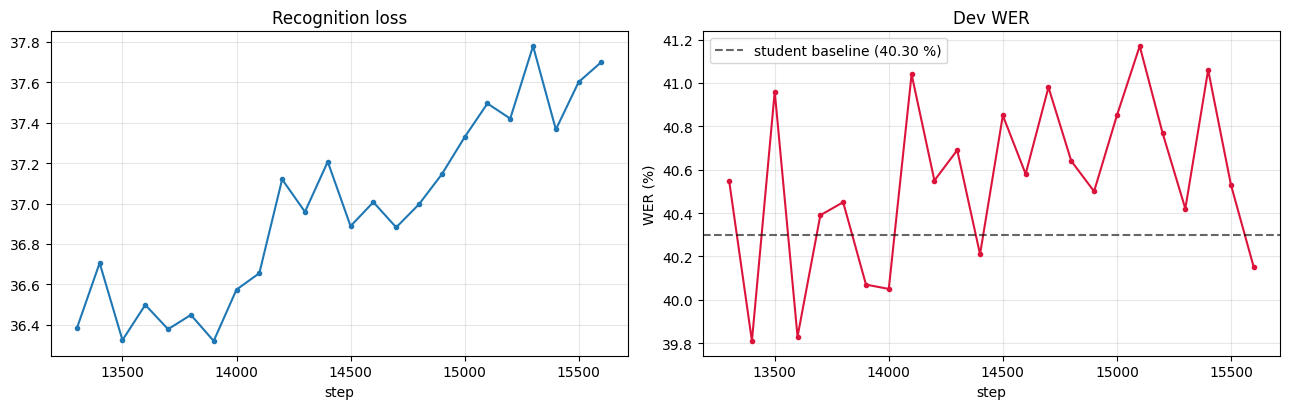

best dev WER: 39.81 % @ step 13400


In [7]:
import re, os
import matplotlib.pyplot as plt

val_file = os.path.join(PARAMS['model_dir'], 'validations.txt')
steps, loss_h, wer_h = [], [], []
if os.path.exists(val_file):
    for line in open(val_file):
        m_step = re.search(r'Steps:\s*(\d+)', line)
        m_wer  = re.search(r'WER\s+([\d.]+)', line)              # "WER 38.71", senza ':'
        m_loss = re.search(r'Recognition Loss:\s*([\d.eE+-]+)', line)
        if m_step and m_wer:
            steps.append(int(m_step.group(1)))
            wer_h.append(float(m_wer.group(1)))
            loss_h.append(float(m_loss.group(1)) if m_loss else float('nan'))

if steps:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
    ax1.plot(steps, loss_h, marker='o', ms=3)
    ax1.set_title('Recognition loss'); ax1.set_xlabel('step'); ax1.grid(alpha=.3)
    ax2.plot(steps, wer_h, marker='o', ms=3, color='crimson')
    ax2.axhline(40.30, ls='--', c='k', alpha=.6, label='student baseline (40.30 %)')
    ax2.set_title('Dev WER'); ax2.set_xlabel('step'); ax2.set_ylabel('WER (%)')
    ax2.grid(alpha=.3); ax2.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PARAMS['model_dir'], 'training_curves.png'), dpi=110)
    plt.show()
    bi = min(range(len(wer_h)), key=lambda i: wer_h[i])
    print(f'best dev WER: {wer_h[bi]:.2f} % @ step {steps[bi]}')
else:
    print('no validations.txt yet — run the training cell first')

## 7 — Test-set evaluation (beam search per the config)

In [8]:
from main.prediction import test as run_test
_best = os.path.join(PARAMS['model_dir'], 'best.ckpt')
if os.path.exists(_best):
    run_test(cfg_file=ACTIVE_CFG, ckpt=_best,
             output_path=os.path.join(PARAMS['model_dir'], 'test_output'))
else:
    print('best checkpoint not found:', _best)

2026-07-09 23:31:48,241 - ------------------------------------------------------------
2026-07-09 23:31:48,241 - [DEV] partition [RECOGNITION] experiment [BW]: 1


COPE:  False


2026-07-09 23:32:01,414 - finished in 13.1731s 
2026-07-09 23:32:01,415 - ************************************************************
2026-07-09 23:32:01,415 - [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 1
	WER 39.81	(DEL: 14.54,	INS: 2.83,	SUB: 22.44)
2026-07-09 23:32:01,416 - ************************************************************
2026-07-09 23:32:01,416 - ------------------------------------------------------------
2026-07-09 23:32:01,416 - [DEV] partition [RECOGNITION] experiment [BW]: 2
2026-07-09 23:32:24,115 - finished in 22.6987s 
2026-07-09 23:32:24,115 - ************************************************************
2026-07-09 23:32:24,116 - [DEV] partition [RECOGNITION] results:
	New Best CTC Decode Beam Size: 2
	WER 39.54	(DEL: 14.11,	INS: 2.85,	SUB: 22.57)
2026-07-09 23:32:24,116 - ************************************************************
2026-07-09 23:32:24,116 - ------------------------------------------------------------
2026-07-09 23:3